In [2]:
# Loading Data
import pandas as pd

trades = pd.read_csv('historical_data.csv') # Historical Data
sentiment = pd.read_csv('fear_greed_index.csv') # Fear Greed Data

In [4]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [6]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [8]:
# Number of Rows and Columns
print("Trades shape:", trades.shape)
print("Sentiment shape:", sentiment.shape)

Trades shape: (211224, 16)
Sentiment shape: (2644, 4)


In [10]:
# Information
print(trades.info())
print("\n-----------------\n")
print(sentiment.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [12]:
# Checking for null/missing values
print("Missing values in Trades:\n")
print(trades.isnull().sum())

print("\n-----------------\n")

print("Missing values in Sentiment:\n")
print(sentiment.isnull().sum())

Missing values in Trades:

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

-----------------

Missing values in Sentiment:

timestamp         0
value             0
classification    0
date              0
dtype: int64


In [16]:
# Checking for duplicates
print("Duplicate rows in Trades:", trades.duplicated().sum())
print("Duplicate rows in Sentiment:", sentiment.duplicated().sum())

Duplicate rows in Trades: 0
Duplicate rows in Sentiment: 0


In [24]:
# Convert timestamps and align the datasets by date (daily level is fine)
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)
sentiment['date'] = pd.to_datetime(sentiment['date'])

print(trades['Timestamp IST'].head())
print(sentiment['date'].head())

0   2024-12-02 22:50:00
1   2024-12-02 22:50:00
2   2024-12-02 22:50:00
3   2024-12-02 22:50:00
4   2024-12-02 22:50:00
Name: Timestamp IST, dtype: datetime64[ns]
0   2018-02-01
1   2018-02-02
2   2018-02-03
3   2018-02-04
4   2018-02-05
Name: date, dtype: datetime64[ns]


In [26]:
# Extract only date
trades['date'] = trades['Timestamp IST'].dt.date
sentiment['date'] = sentiment['date'].dt.date

# Check
print(trades[['Timestamp IST','date']].head())
print(sentiment[['date']].head())

        Timestamp IST        date
0 2024-12-02 22:50:00  2024-12-02
1 2024-12-02 22:50:00  2024-12-02
2 2024-12-02 22:50:00  2024-12-02
3 2024-12-02 22:50:00  2024-12-02
4 2024-12-02 22:50:00  2024-12-02
         date
0  2018-02-01
1  2018-02-02
2  2018-02-03
3  2018-02-04
4  2018-02-05


In [28]:
# Merging both data on date
merged = pd.merge(trades, sentiment, on='date', how='inner')

print(merged.shape)
merged.head()

(211218, 20)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed


In [32]:
# Daily PnL per trader
daily_pnl = merged.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()

daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


In [34]:
daily_trades = merged.groupby(['Account', 'date']).size().reset_index(name='num_trades')

daily_trades.head()

,Account,date,num_trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,177
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,68
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,40
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,12
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,27


In [36]:
# Average Trade Size
avg_size = merged.groupby(['Account', 'date'])['Size USD'].mean().reset_index(name='avg_trade_size')

avg_size.head()

,Account,date,avg_trade_size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,5089.718249
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,7976.664412
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,23734.500000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,28186.666667
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,17248.148148


In [38]:
long_short = merged.groupby(['Account', 'date', 'Side']).size().unstack(fill_value=0)

# Avoid division by zero
long_short['long_short_ratio'] = long_short['BUY'] / (long_short['SELL'] + 1)

long_short = long_short.reset_index()

long_short.head()

Side,Account,date,BUY,SELL,long_short_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0,177,0.00
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0,68,0.00
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0,40,0.00
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,12,0,12.00
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,12,15,0.75


In [40]:
# Keep only needed columns from sentiment
sentiment_small = sentiment[['date', 'classification']]

# Merge with daily_pnl
data = pd.merge(daily_pnl, sentiment_small, on='date', how='inner')

data.head()

,Account,date,Closed PnL,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,Extreme Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,Extreme Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,Extreme Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,Extreme Greed


In [42]:
pnl_by_sentiment = data.groupby('classification')['Closed PnL'].mean().reset_index()

pnl_by_sentiment

,classification,Closed PnL
0,Extreme Fear,4619.439053
1,Extreme Greed,5161.922644
2,Fear,5328.818161
3,Greed,3318.100730
4,Neutral,3438.618818


In [68]:
order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

pnl_by_sentiment['classification'] = pd.Categorical(
    pnl_by_sentiment['classification'],
    categories=order,
    ordered=True
)

pnl_by_sentiment = pnl_by_sentiment.sort_values('classification')

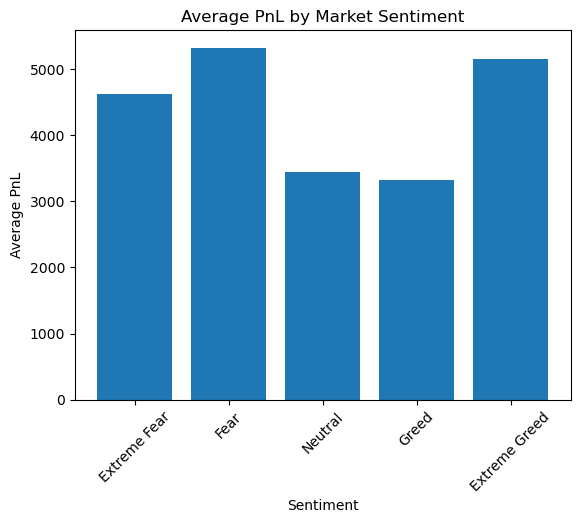

In [70]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(pnl_by_sentiment['classification'], pnl_by_sentiment['Closed PnL'])
plt.xticks(rotation=45)
plt.title("Average PnL by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average PnL")
plt.show()

#### Trader performance (PnL) is higher during Fear compared to Greed periods.

In [73]:
# Merge trades count with sentiment
trades_sentiment = pd.merge(daily_trades, sentiment_small, on='date', how='inner')

activity = trades_sentiment.groupby('classification')['num_trades'].mean().reset_index()

activity

,classification,num_trades
0,Extreme Fear,133.750000
1,Extreme Greed,76.030418
2,Fear,98.153968
3,Greed,77.628086
4,Neutral,100.228723


#### Traders trade more during Fear (especially Extreme Fear)

In [78]:
order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

activity['classification'] = pd.Categorical(
    activity['classification'],
    categories=order,
    ordered=True
)

activity = activity.sort_values('classification')

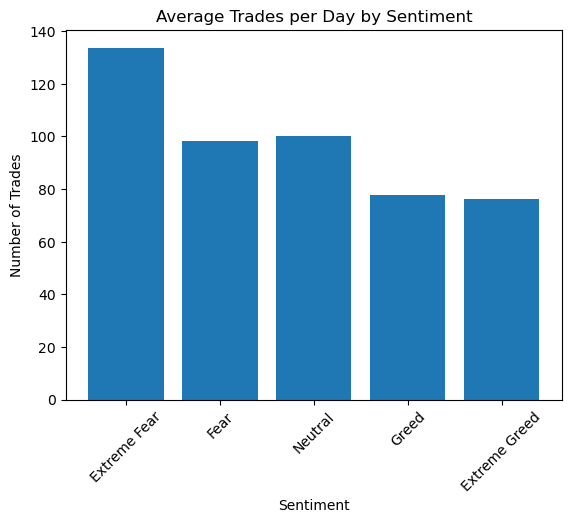

In [80]:
plt.figure()
plt.bar(activity['classification'], activity['num_trades'])
plt.xticks(rotation=45)
plt.title("Average Trades per Day by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Trades")
plt.show()

#### Trading activity is highest during Extreme Fear and lowest during Greed periods.

In [83]:
# Merge avg trade size with sentiment
size_sentiment = pd.merge(avg_size, sentiment_small, on='date', how='inner')

size_analysis = size_sentiment.groupby('classification')['avg_trade_size'].mean().reset_index()

size_analysis

,classification,avg_trade_size
0,Extreme Fear,6773.464125
1,Extreme Greed,5371.637182
2,Fear,8975.928546
3,Greed,6427.866594
4,Neutral,6963.694861


In [85]:
order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

size_analysis['classification'] = pd.Categorical(
    size_analysis['classification'],
    categories=order,
    ordered=True
)

size_analysis = size_analysis.sort_values('classification')

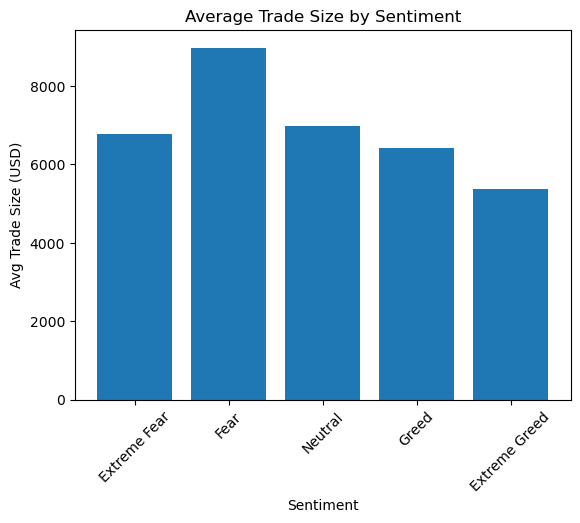

In [89]:
plt.figure()
plt.bar(size_analysis['classification'], size_analysis['avg_trade_size'])
plt.xticks(rotation=45)
plt.title("Average Trade Size by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Avg Trade Size (USD)")
plt.show()

#### Traders take larger positions during Fear than during Greed.

### If market sentiment is Fear, traders should consider increasing trade size and activity, as historical data shows higher profitability during these periods.

### If market sentiment is Greed, traders should reduce trade frequency and position size, as performance tends to be lower during these periods.

### This analysis examined the relationship between market sentiment and trader behavior. Results show that traders perform better during Fear periods, with higher profitability, increased trading activity, and larger trade sizes. In contrast, Greed periods are associated with lower performance and reduced activity. Based on these findings, strategies should focus on increasing participation during Fear while applying risk control during Greed.

In [95]:
from sklearn.cluster import KMeans

# Merge features
features = pd.merge(daily_pnl, daily_trades, on=['Account','date'])
features = pd.merge(features, avg_size, on=['Account','date'])

# Aggregate per trader
trader_features = features.groupby('Account').mean(numeric_only=True).reset_index()

# Select variables
X = trader_features[['Closed PnL', 'num_trades', 'avg_trade_size']]

X.head()

,Closed PnL,num_trades,avg_trade_size
0,66676.242499,159.083333,33569.102224
1,920.871548,140.000000,4359.830930
2,-5869.682610,317.416667,11057.118419
3,817.684040,82.166667,484.844294
4,2444.318913,46.942029,2553.757037


In [97]:
kmeans = KMeans(n_clusters=3, random_state=42)
trader_features['cluster'] = kmeans.fit_predict(X)

trader_features.head()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Account,Closed PnL,num_trades,avg_trade_size,cluster
0,0x083384f897ee0f19899168e3b1bec365f52a9012,66676.242499,159.083333,33569.102224,2
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,920.871548,140.000000,4359.830930,1
2,0x271b280974205ca63b716753467d5a371de622ab,-5869.682610,317.416667,11057.118419,1
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,817.684040,82.166667,484.844294,1
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,2444.318913,46.942029,2553.757037,1


In [99]:
cluster_summary = trader_features.groupby('cluster')[['Closed PnL','num_trades','avg_trade_size']].mean()

cluster_summary

,Closed PnL,num_trades,avg_trade_size
cluster,,,
0,10942.426620,168.467043,16773.335828
1,2474.514289,83.761531,3842.728943
2,66676.242499,159.083333,33569.102224


### Clustering revealed three distinct trader segments:
1. High-value traders with high PnL and large trade sizes
2. Consistent traders with moderate activity and returns
3. Low-performing traders with lower activity and profitability